# Диагностика рака молочной железы
## Логистическая регрессия

---

**Задача:** по результатам анализа клеток опухоли определить,
является она **злокачественной** или **доброкачественной**.

**Тип задачи:** классификация — мы предсказываем класс (одно из двух состояний),
а не число.

**Алгоритм:** логистическая регрессия (Logistic Regression).

**Инструменты:** Python, pandas, scikit-learn, matplotlib, seaborn.

Каждое действие подробно объясняется в комментариях,
чтобы разобраться мог даже человек, который программирует впервые.

## 1. Зависимости

    pandas          — работа с таблицами
    numpy           — математика и массивы чисел
    scikit-learn    — машинное обучение (модели, метрики, датасеты)
    matplotlib      — построение графиков
    seaborn         — статистические графики

Если вы запускаете ноутбук в Google Colab, выполните:

    !pip install -q pandas numpy scikit-learn matplotlib seaborn

In [1]:
# ============================================================
# ЯЧЕЙКА ЗАВИСИМОСТЕЙ
# Подключаем всё, что понадобится в этом ноутбуке.
# ============================================================

# pandas — работа с табличными данными. Сокращаем имя до pd.
import pandas as pd

# numpy — математические операции и массивы чисел. Сокращаем до np.
import numpy as np

# matplotlib.pyplot — рисование графиков. Сокращаем до plt.
import matplotlib.pyplot as plt

# seaborn — красивые статистические графики поверх matplotlib. Сокращаем до sns.
import seaborn as sns

# ------------------------------------------------------------
# Инструменты машинного обучения из scikit-learn
# ------------------------------------------------------------

# load_breast_cancer — функция загрузки нужного нам датасета.
from sklearn.datasets import load_breast_cancer

# train_test_split — делит данные на обучающую и тестовую части.
from sklearn.model_selection import train_test_split

# LogisticRegression — сама модель логистической регрессии.
from sklearn.linear_model import LogisticRegression

# StandardScaler — приводит все признаки к одному масштабу.
# Для логистической регрессии это важно: без этого признаки
# с большими числами будут "забивать" признаки с маленькими.
from sklearn.preprocessing import StandardScaler

# Pipeline — объединяет несколько шагов обработки в одну цепочку.
# Удобно и безопасно: масштабирование и модель всегда работают вместе.
from sklearn.pipeline import Pipeline

# ------------------------------------------------------------
# Метрики качества классификации
# ------------------------------------------------------------

# accuracy_score      — доля правильных ответов.
# precision_score     — точность: насколько можно верить положительному прогнозу.
# recall_score        — полнота: какую часть больных мы нашли.
# f1_score            — баланс между точностью и полнотой.
# confusion_matrix    — таблица "сколько каких ответов дала модель".
# classification_report — готовый отчёт со всеми метриками сразу.
# roc_auc_score       — качество разделения классов во всём диапазоне порогов.
# roc_curve           — точки для построения ROC-кривой.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)


# sklearn целиком нужен, чтобы вывести его версию.
import sklearn

# ------------------------------------------------------------
# Настройки оформления графиков
# ------------------------------------------------------------

# Аккуратная тема с белым фоном и сеткой.
sns.set_theme(style="whitegrid")

# Размер графиков по умолчанию.
plt.rcParams["figure.figsize"] = (10, 6)

# Размер базового шрифта.
plt.rcParams["font.size"] = 11

# Не обрезать столбцы таблиц при выводе.
pd.set_option("display.max_columns", None)

# Показывать все строки, если их немного.
pd.set_option("display.max_rows", 100)

# ------------------------------------------------------------
# Печатаем версии — это важно для воспроизводимости результата.
# ------------------------------------------------------------
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("scikit-learn :", sklearn.__version__)
print("matplotlib   :", plt.matplotlib.__version__)
print("seaborn      :", sns.__version__)
print()
print("Все библиотеки подключены успешно.")

pandas       : 3.0.5
numpy        : 2.5.3
scikit-learn : 1.9.1
matplotlib   : 3.11.2
seaborn      : 0.13.2

Все библиотеки подключены успешно.


## 2. Описание датасета

**Источник:** встроенный набор данных Breast Cancer Wisconsin
библиотеки scikit-learn. Данные собраны в клинике Висконсинского
университета — это реальные измерения, а не учебный пример.

**Размер:** 569 образцов (пациентов), 30 числовых признаков.

**Что измеряется.** Для каждой опухоли берётся изображение клеток
и считается 10 характеристик ядра:

* radius — радиус;
* texture — текстура (шероховатость);
* perimeter — периметр;
* area — площадь;
* smoothness — гладкость;
* compactness — компактность;
* concavity — вогнутость;
* concave points — число вогнутых участков;
* symmetry — симметричность;
* fractal dimension — фрактальная размерность.

Каждая характеристика посчитана **в трёх вариантах**: среднее значение (mean),
стандартная ошибка (error) и среднее по трём худшим клеткам (worst).
Получается 10 × 3 = 30 признаков.

**Целевая переменная:** бинарный класс.

* **0 = malignant (злокачественная)** — 212 образцов;
* **1 = benign (доброкачественная)** — 357 образцов.

**Важно про порядок классов!** В этом датасете злокачественная опухоль — это
класс **0**, а доброкачественная — **1**. Ошибка здесь стоит дорого,
поэтому мы обязательно проверим соответствие в коде ниже.

## 3. Загрузка данных

In [2]:
# Загружаем датасет. Функция возвращает объект, в котором лежат
# и признаки, и ответы, и описания — всё в одном месте.
breast_cancer = load_breast_cancer()

# breast_cancer.data — массив чисел с признаками.
# Превращаем его в таблицу pandas с понятными названиями столбцов.
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)

# breast_cancer.target — ответы (0 или 1). Превращаем в столбец Series.
y = pd.Series(breast_cancer.target, name="diagnosis")

# Печатаем размеры, чтобы убедиться, что всё загрузилось.
print("Признаки X :", X.shape)
print("Ответы y   :", y.shape)
print()

# Печатаем названия классов так, как их понимает scikit-learn.
# target_names[0] соответствует значению 0, target_names[1] — значению 1.
print("Классы по версии scikit-learn:")
for code_value, class_name in enumerate(breast_cancer.target_names):
    print(f"  {code_value} = {class_name}")

Признаки X : (569, 30)
Ответы y   : (569,)

Классы по версии scikit-learn:
  0 = malignant
  1 = benign


### Проверка соответствия классов — критически важный шаг

Прежде чем идти дальше, убедимся, что мы правильно понимаем,
какой номер какому диагнозу соответствует. Иначе все выводы будут ложными.

In [3]:
# Считаем, сколько образцов каждого класса в датасете.
# value_counts() считает, сколько раз встречается каждое значение.
# sort_index() сортирует результат по номеру класса: сначала 0, потом 1.
counts = y.value_counts().sort_index()

print("Количество образцов по классам:")
for code_value, n in counts.items():
    # Подставляем название класса по его номеру.
    name = breast_cancer.target_names[code_value]
    # Считаем долю этого класса от общего числа.
    share = n / len(y) * 100
    print(f"  {code_value} = {name:9s} : {n:4d} образцов ({share:.1f} %)")

print()
print("Вывод: 0 = злокачественная (malignant), 1 = доброкачественная (benign).")
print("Класс 1 (доброкачественная) встречается чаще — примерно 63 % случаев.")

Количество образцов по классам:
  0 = malignant :  212 образцов (37.3 %)
  1 = benign    :  357 образцов (62.7 %)

Вывод: 0 = злокачественная (malignant), 1 = доброкачественная (benign).
Класс 1 (доброкачественная) встречается чаще — примерно 63 % случаев.


## 4. Разведочный анализ данных (EDA)

Проверим данные по порядку:

1. общий вид таблицы;
2. пропуски;
3. дубликаты;
4. аномалии и выбросы;
5. распределения признаков;
6. корреляции между признаками;
7. баланс классов.

### 4.1 Первый взгляд на данные

In [4]:
# .shape показывает размер таблицы: (число строк, число столбцов).
print("Размер таблицы признаков:", X.shape)

# .head() выводит первые пять строк таблицы.
X.head()

Размер таблицы признаков: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# .info() показывает по каждому столбцу имя, число непустых значений и тип.
# Столбцов много (30), поэтому вывод будет длинным — это нормально.
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [6]:
# .describe() считает статистику по каждому столбцу:
# количество, среднее, стандартное отклонение, минимум, квартили, максимум.
# .T переворачивает таблицу, чтобы всё поместилось на экран.
# .round(2) округляет числа до двух знаков для читаемости.
X.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


Обратите внимание на разброс значений: признак **area** доходит до нескольких
тысяч, а **smoothness** измеряется десятыми долями. Это и есть та самая
разномасштабность, из-за которой нам понадобится стандартизация признаков.

### 4.2 Проверка пропусков

Пропуск — пустая ячейка. Модель на таких данных либо упадёт с ошибкой,
либо обучится неправильно, поэтому проверяем в первую очередь.

In [7]:
# .isnull() помечает пустые ячейки как True.
# .sum() складывает True как единицы — получаем число пропусков в столбце.
missing = X.isnull().sum()

# Оставляем только те столбцы, где пропуски действительно есть.
# Если список пуст — пропусков нет вообще.
missing_nonzero = missing[missing > 0]

print("Столбцов с пропусками:", len(missing_nonzero))
if len(missing_nonzero) == 0:
    print("  Пропусков в датасете нет.")
else:
    print(missing_nonzero)

print()
print("Всего пропусков:", missing.sum(), "из", X.size, "ячеек")

# Проверим и целевую переменную: в ней тоже не должно быть пусто.
print("Пропусков в целевой переменной:", y.isnull().sum())

Столбцов с пропусками: 0
  Пропусков в датасете нет.

Всего пропусков: 0 из 17070 ячеек
Пропусков в целевой переменной: 0


**Вывод:** пропусков нет. Датасет подготовлен аккуратно,
заполнять или удалять ничего не нужно.

### 4.3 Проверка дубликатов

Дубликат — строка, полностью повторяющая другую. Дубликаты опасны тем,
что могут попасть и в обучающую, и в тестовую часть одновременно.
Тогда модель "узнаёт" ответ, который уже видела, и метрики завышаются.

In [8]:
# Собираем признаки и ответ в одну таблицу — так удобнее считать дубликаты.
df = X.copy()
df["diagnosis"] = y

# .duplicated() помечает повторы как True, .sum() считает их количество.
n_dup_full = df.duplicated().sum()

# Считаем дубликаты только по признакам, не глядя на диагноз.
n_dup_features = X.duplicated().sum()

print("Полных дубликатов (признаки + диагноз):", n_dup_full)
print("Дубликатов только по признакам       :", n_dup_features)
print()

# Если дубликаты по признакам есть, посмотрим на них внимательно.
if n_dup_features > 0:
    print("Найденные повторяющиеся строки по признакам:")
    # duplicated(keep=False) помечает все копии, а не только вторую и далее.
    dup_rows = X[X.duplicated(keep=False)]
    # Сортируем, чтобы одинаковые строки стояли рядом.
    display(dup_rows.sort_values(by=list(X.columns)).head(10))
else:
    print("Повторяющихся строк по признакам нет.")

Полных дубликатов (признаки + диагноз): 0
Дубликатов только по признакам       : 0

Повторяющихся строк по признакам нет.


**Вывод:** полных дубликатов в датасете нет, данные чистые.
Если повторы по признакам всё-таки нашлись — это обычно разные пациенты
со случайно совпавшими округлёнными измерениями. Удалять их не следует,
так как диагноз у них может отличаться.

### 4.4 Поиск аномалий и выбросов

**Выброс** — значение, сильно выбивающееся из общего ряда.
Медицинские измерения особенно подвержены выбросам: крупная опухоль
даёт большие значения радиуса и площади, и это не ошибка, а реальность.

Ищем выбросы по правилу **межквартильного размаха (IQR)**:

* Q1 — первый квартиль (25 % значений ниже него);
* Q3 — третий квартиль (75 % значений ниже него);
* IQR = Q3 − Q1;
* выброс — всё, что ниже Q1 − 1.5 × IQR или выше Q3 + 1.5 × IQR.

In [9]:
# Функция считает количество выбросов в одном столбце.
def count_outliers(series):
    """Считает выбросы по правилу межквартильного размаха (IQR)."""

    # Первый и третий квартили.
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    # Межквартильный размах — ширина центральной половины данных.
    iqr = q3 - q1

    # Границы: ниже нижней и выше верхней — выбросы.
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Считаем, сколько значений вышло за границы.
    # Символ | означает "или": значение меньше нижней ИЛИ больше верхней.
    return int(((series < lower) | (series > upper)).sum())


# Пройдём по всем 30 признакам и соберём статистику по выбросам.
rows = []
for col in X.columns:
    n_out = count_outliers(X[col])
    rows.append({
        "Признак": col,
        "Выбросов": n_out,
        "Доля, %": round(n_out / len(X) * 100, 2),
    })

# Превращаем список словарей в таблицу и сортируем по доле выбросов.
outliers_df = pd.DataFrame(rows).sort_values("Доля, %", ascending=False)

# Смотрим на первые 12 самых "загрязнённых" признаков.
print("Признаки с наибольшей долей выбросов:")
outliers_df.head(12).reset_index(drop=True)

Признаки с наибольшей долей выбросов:


,Признак,Выбросов,"Доля, %"
0,area error,65,11.42
1,radius error,38,6.68
2,perimeter error,38,6.68
3,worst area,35,6.15
4,smoothness error,30,5.27
5,fractal dimension error,28,4.92
6,compactness error,28,4.92
7,symmetry error,27,4.75
8,mean area,25,4.39
9,worst fractal dimension,24,4.22


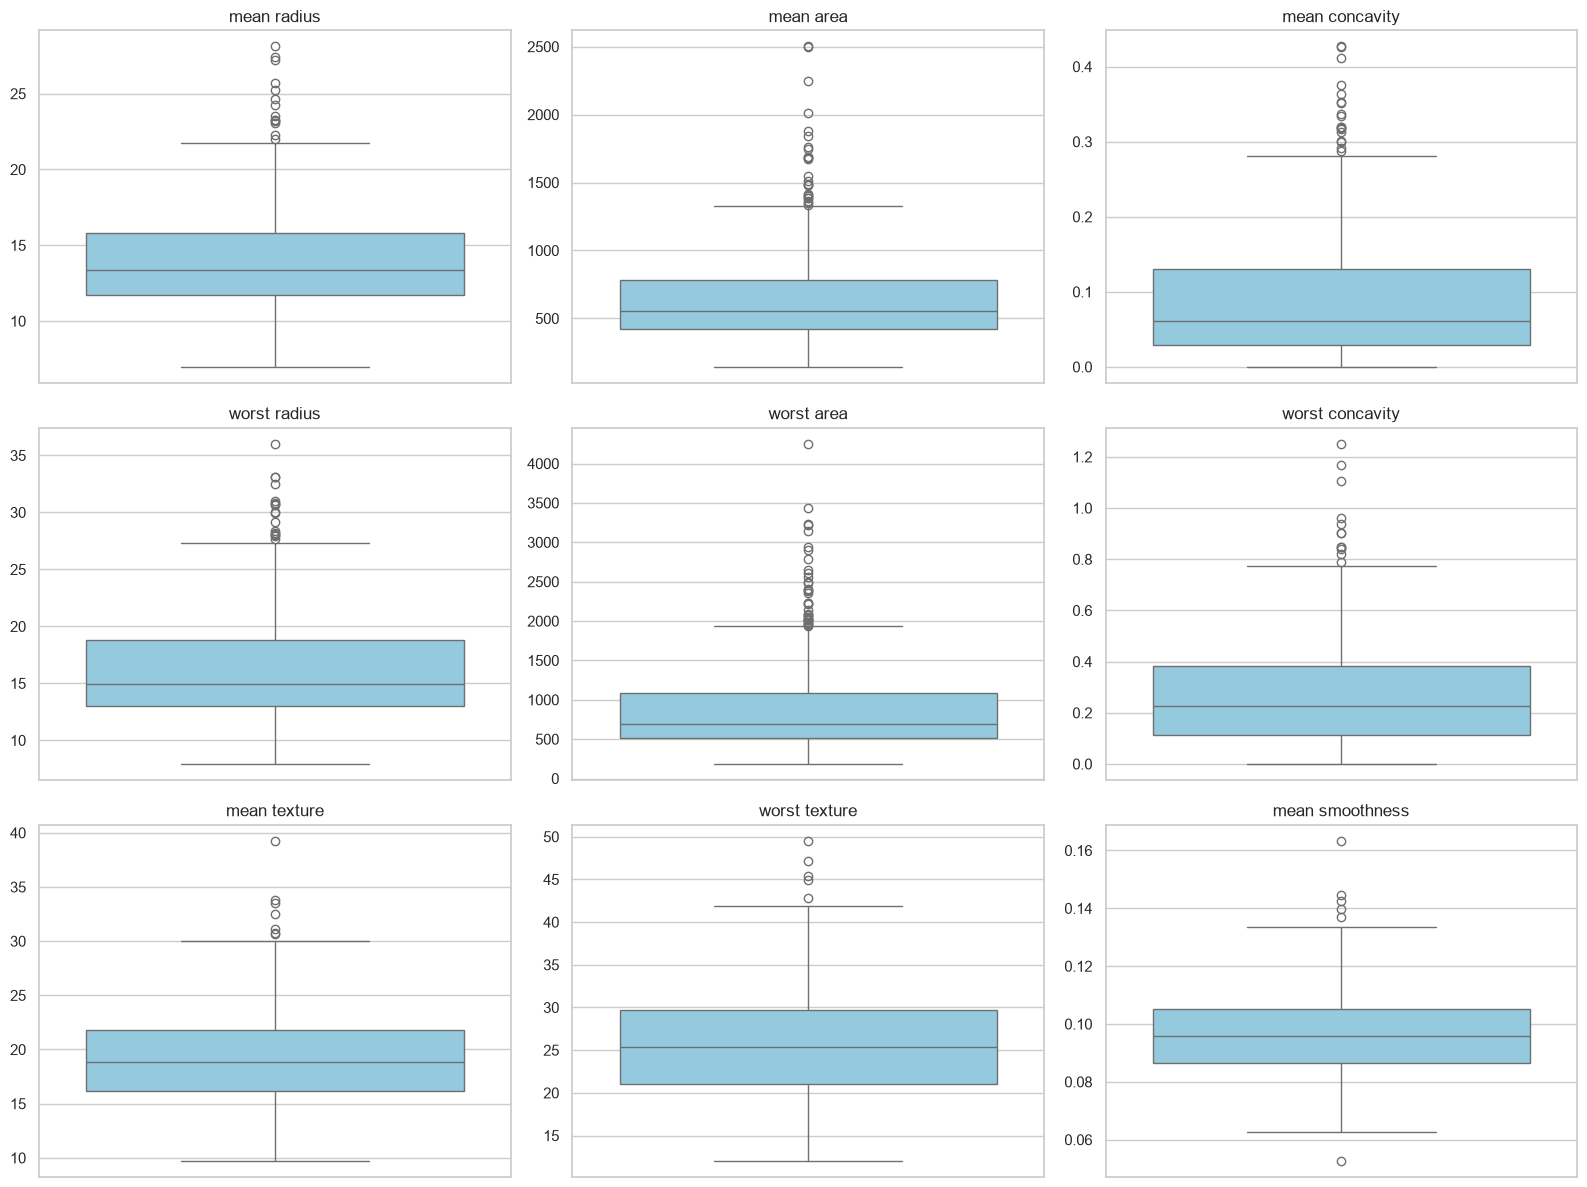

In [10]:
# Посмотрим на выбросы глазами. Возьмём 9 самых показательных признаков.
cols_to_plot = [
    "mean radius", "mean area", "mean concavity",
    "worst radius", "worst area", "worst concavity",
    "mean texture", "worst texture", "mean smoothness",
]

# Создаём сетку графиков 3 на 3.
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# Превращаем таблицу осей в плоский список.
axes = axes.ravel()

# Рисуем "ящик с усами" для каждого признака.
for i, col in enumerate(cols_to_plot):
    # Прямоугольник — центральная половина данных, точки за усами — выбросы.
    sns.boxplot(y=X[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col)
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

**Что мы увидели:**

* Выбросы есть почти во всех признаках, и их доля доходит до 10–15 %
  в некоторых столбцах.
* Это **не ошибки измерения**. Большие значения соответствуют крупным
  опухолям, которые чаще оказываются злокачественными. Такие значения
  несут важную информацию для диагноза.
* **Мы их не удаляем.** Удаление выбросов в медицинских данных —
  опасная практика: оно убирает как раз самые тяжёлые случаи.
* Полезный побочный вывод: выбросы подтверждают, что признаки
  сильно разномасштабны и нуждаются в стандартизации.

### 4.5 Распределения признаков

Гистограмма показывает, как часто встречается каждое значение.
Дополнительно построим распределения в разрезе диагноза —
так видно, какие признаки действительно различают классы.

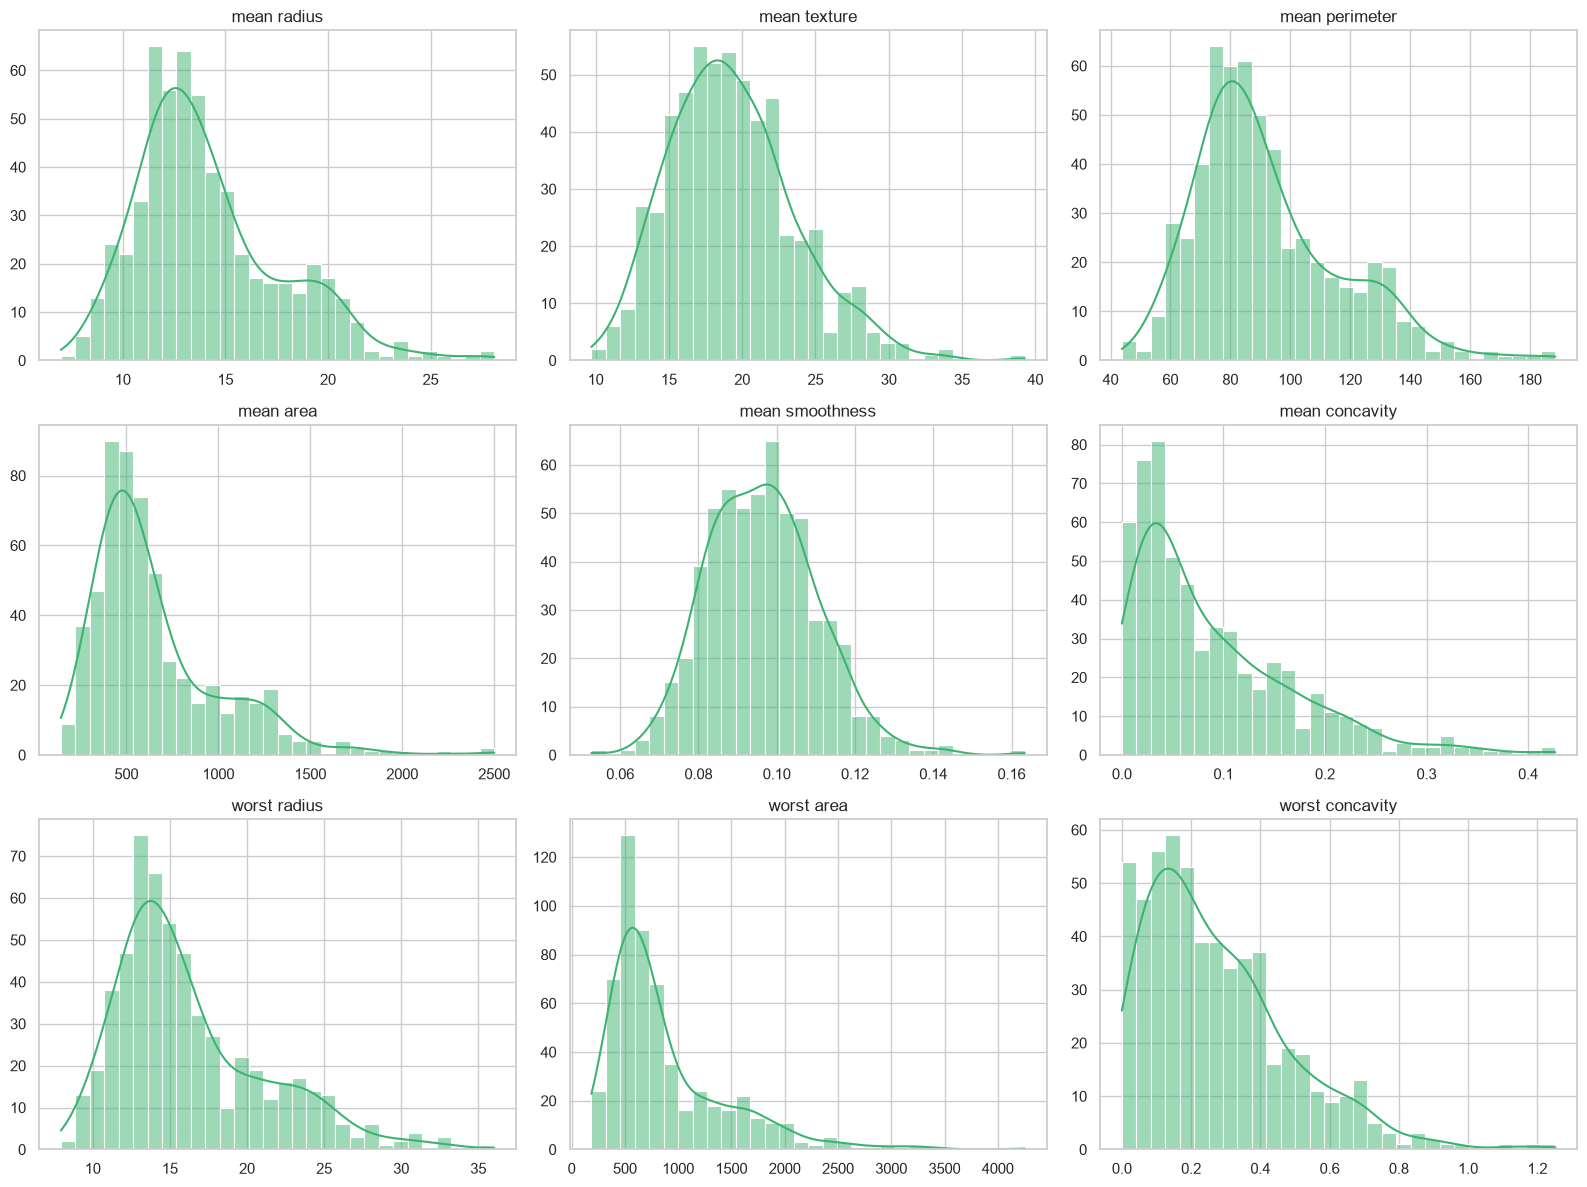

In [11]:
# Возьмём девять ключевых признаков для наглядности.
plot_cols = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean smoothness", "mean concavity",
    "worst radius", "worst area", "worst concavity",
]

# Сетка графиков 3 на 3.
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

# Рисуем по одному признаку на каждый график.
for i, col in enumerate(plot_cols):
    # histplot рисует гистограмму; kde=True добавляет плавную линию плотности.
    # bins=30 — на сколько столбиков разбить диапазон значений.
    sns.histplot(X[col], bins=30, kde=True, ax=axes[i], color="mediumseagreen")
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

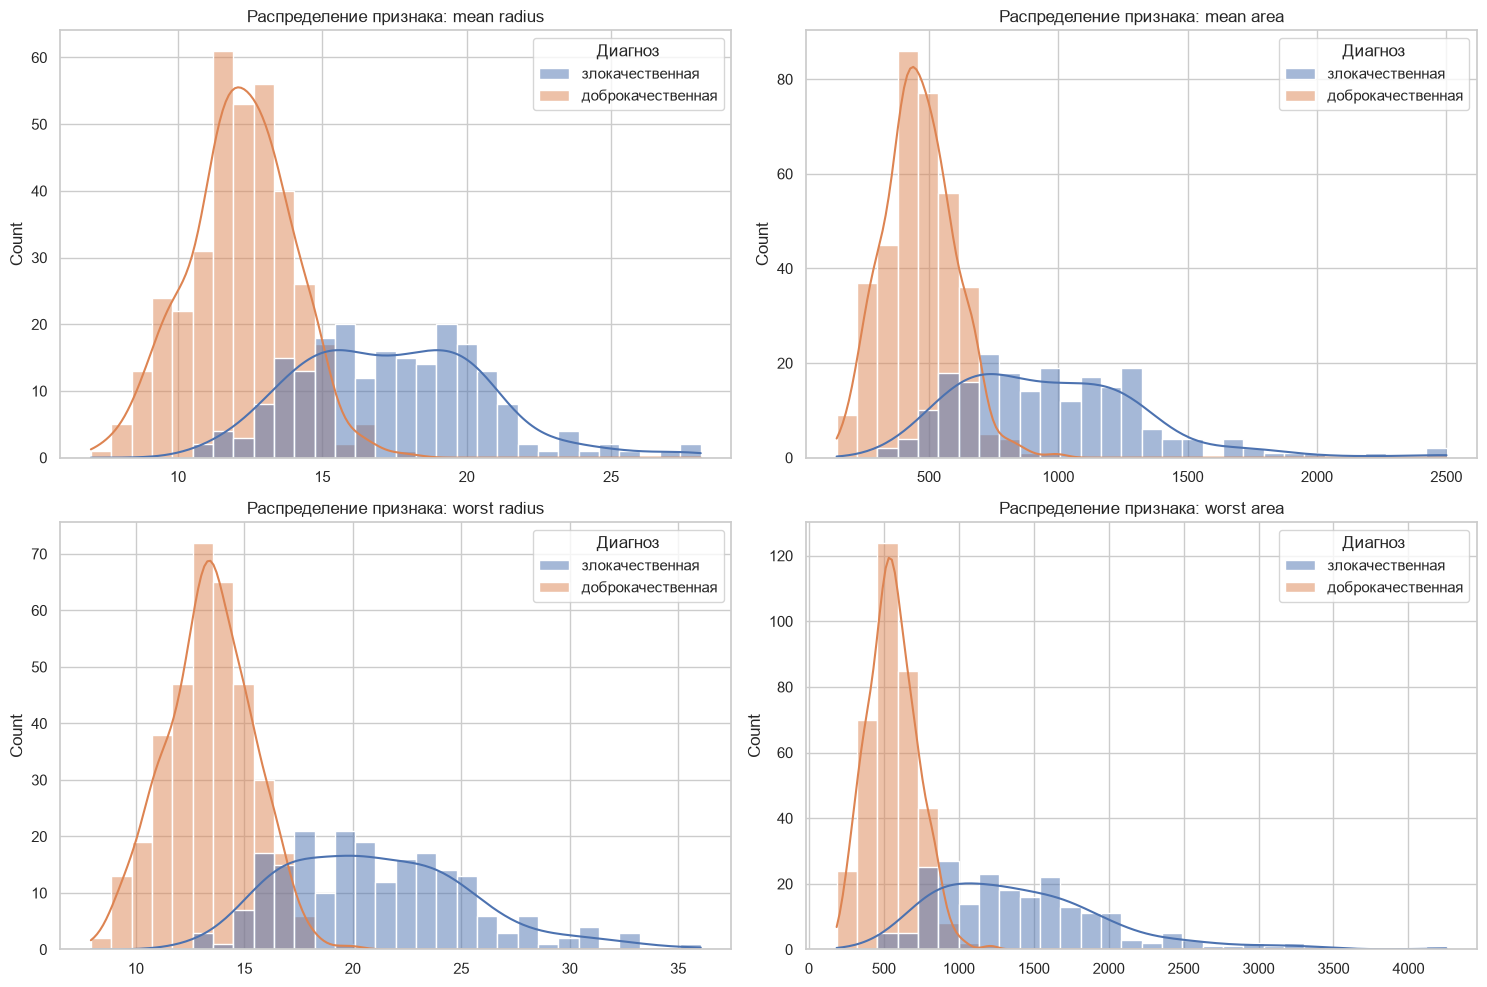

In [12]:
# Теперь самое интересное: сравним распределения отдельно
# для злокачественных и доброкачественных опухолей.
# Если распределения двух классов разъезжаются — признак полезен для диагноза.

# Готовим таблицу: признаки плюс человекочитаемое название диагноза.
df_plot = X.copy()
# map заменяет числа 0 и 1 на текстовые названия классов.
df_plot["Диагноз"] = y.map({0: "злокачественная", 1: "доброкачественная"})

# Берём четыре признака, которые обычно лучше всего разделяют классы.
compare_cols = ["mean radius", "mean area", "worst radius", "worst area"]

# Сетка 2 на 2.
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(compare_cols):
    # hue="Диагноз" раскрашивает распределения по классам.
    # common_norm=False считает плотность каждого класса независимо,
    # иначе малочисленный класс выглядел бы ниже просто потому, что его меньше.
    sns.histplot(
        data=df_plot,
        x=col,
        hue="Диагноз",
        bins=30,
        kde=True,
        ax=axes[i],
        common_norm=False,
    )
    axes[i].set_title(f"Распределение признака: {col}")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

**Что мы увидели:**

* Распределения признаков **mean radius, mean area, worst radius, worst area**
  у двух классов почти не пересекаются. У злокачественных опухолей они
  заметно сдвинуты вправо: опухоль крупнее почти всегда опаснее.
* Признаки формы (smoothness, symmetry, fractal dimension) разделяют классы
  гораздо слабее — их распределения сильно накладываются друг на друга.
* Все признаки имеют правостороннее скошение: большинство значений
  невелики, но есть длинный хвост больших.
* **Практический вывод:** уже на этом этапе видно, что размер опухоли —
  главный признак для диагноза. Это ожидаемо с медицинской точки зрения.

### 4.6 Матрица корреляции

**Корреляция** — число от −1 до +1, показывающее связь двух признаков:

* **+1** — растут вместе;
* **0** — связи нет;
* **−1** — один растёт, другой падает.

Матрица корреляции здесь особенно важна: в этом датасете много
признаков считаются из одних и тех же измерений, поэтому связаны очень сильно.

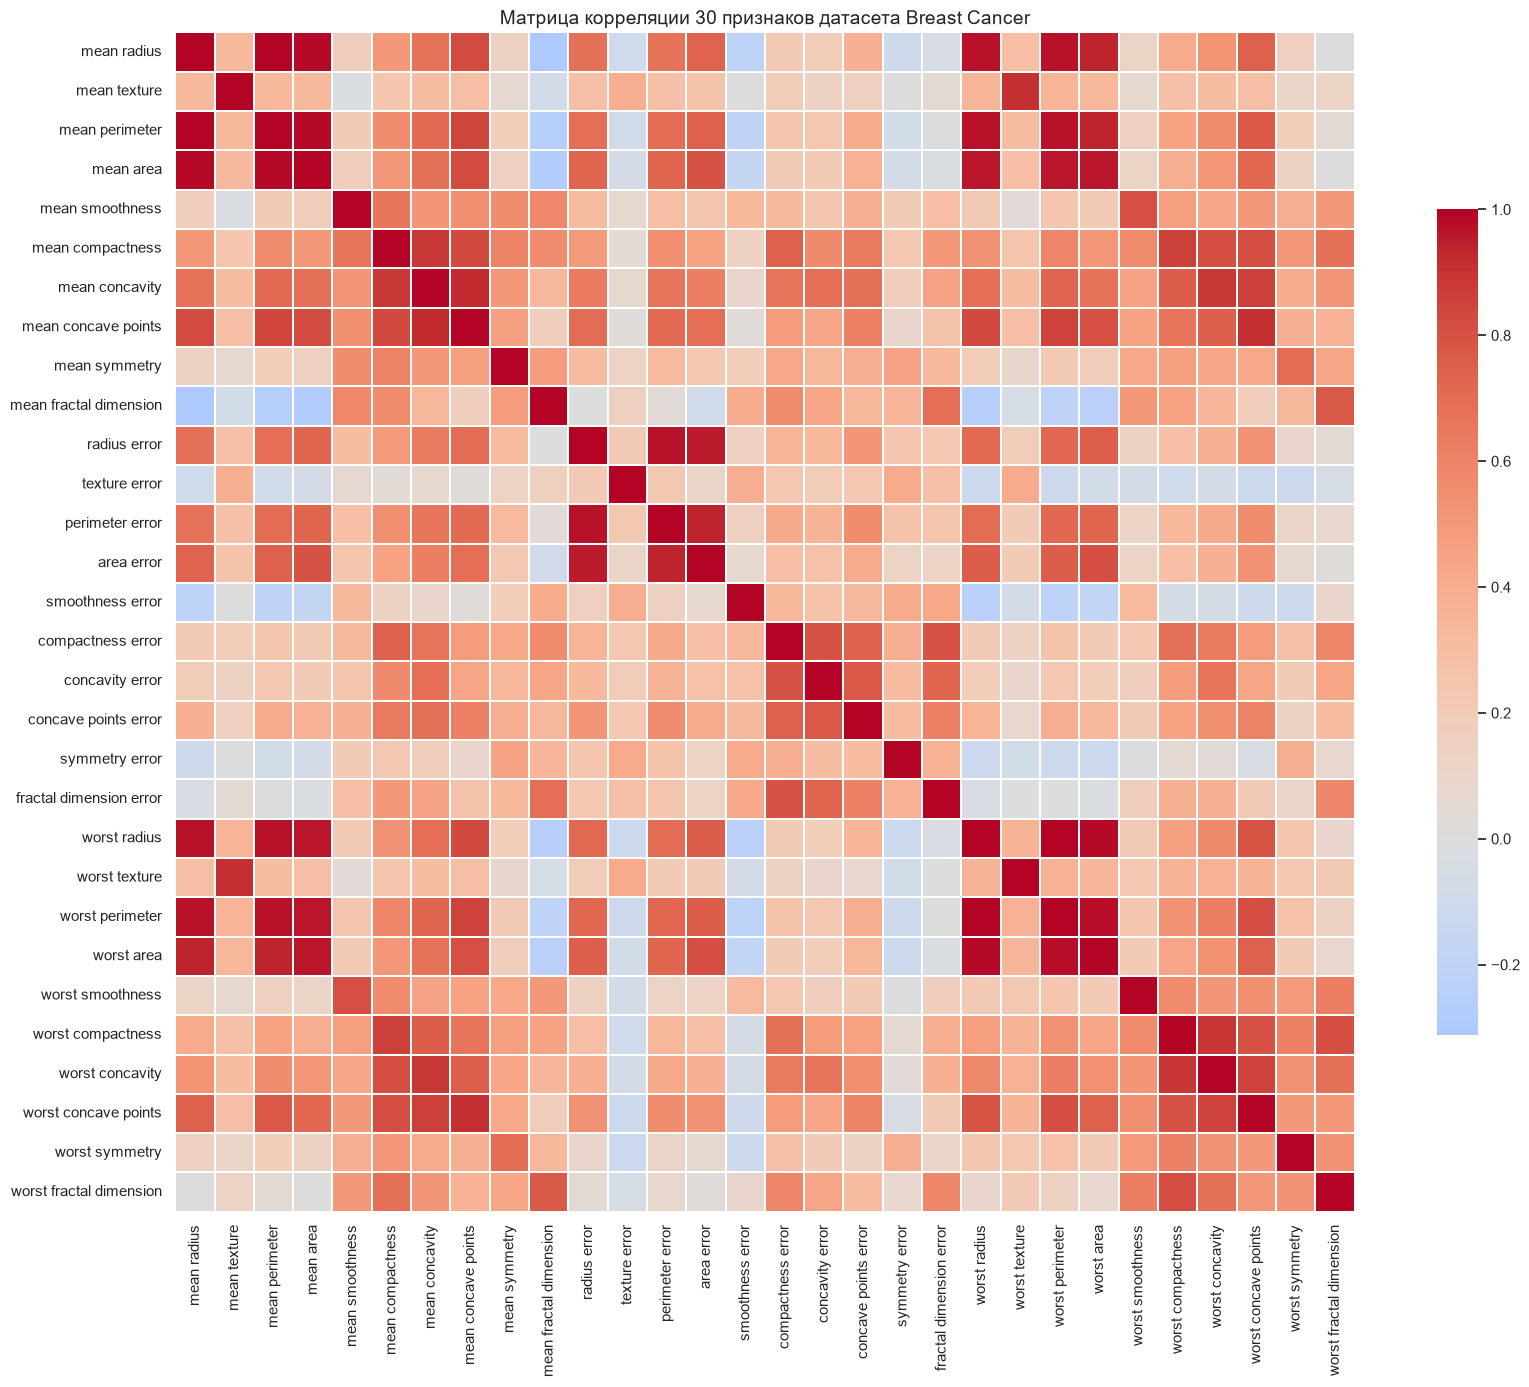

In [13]:
# Считаем корреляцию между всеми парами признаков.
corr_matrix = X.corr()

# Матрица 30 на 30 — рисуем большую картинку.
fig, ax = plt.subplots(figsize=(18, 14))

# Тепловая карта: цвет показывает силу и знак связи.
# annot=False — числа не подписываем: их 900, они сольются в кашу.
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",      # синий — отрицательная связь, красный — положительная
    center=0,             # белый цвет = нулевая корреляция
    square=True,          # квадратные ячейки
    linewidths=0.3,       # тонкая рамка между ячейками
    cbar_kws={"shrink": 0.7},  # цветовая шкала чуть компактнее
    ax=ax,
)

ax.set_title("Матрица корреляции 30 признаков датасета Breast Cancer", fontsize=14)
plt.tight_layout()
plt.show()

Карта почти целиком красная — это важный результат. Он означает,
что подавляющее большинство признаков сильно связаны между собой.

In [14]:
# Найдём самые сильные связи между признаками пара за парой.
# Соберём корреляции в длинную таблицу.

# .stack() превращает матрицу в столбец со всеми парами.
pairs = corr_matrix.stack()

# Убираем связи признака с самим собой — там всегда ровно 1.0.
pairs = pairs[pairs < 1.0]

# Превращаем в таблицу, сортируем по убыванию корреляции,
# берём первые 15 самых сильных пар.
top_pairs = (
    pairs.sort_values(ascending=False)
    .head(15)
    .reset_index()
)

# Даём столбцам понятные имена.
top_pairs.columns = ["Признак 1", "Признак 2", "Корреляция"]

# Округляем значения для читаемости.
top_pairs["Корреляция"] = top_pairs["Корреляция"].round(4)

print("15 самых сильно связанных пар признаков:")
top_pairs

15 самых сильно связанных пар признаков:


,Признак 1,Признак 2,Корреляция
0,mean radius,mean perimeter,0.9979
1,mean perimeter,mean radius,0.9979
2,worst perimeter,worst radius,0.9937
3,worst radius,worst perimeter,0.9937
4,mean radius,mean area,0.9874
5,mean area,mean radius,0.9874
6,mean area,mean perimeter,0.9865
7,mean perimeter,mean area,0.9865
8,worst radius,worst area,0.9840
9,worst area,worst radius,0.9840


In [15]:
# Отдельно посмотрим, какие признаки сильнее всего связаны с диагнозом.
# y содержит 0 и 1, поэтому корреляция с ним показывает,
# насколько признак "тянет" диагноз в сторону доброкачественного.

# Добавляем диагноз к таблице признаков.
corr_with_y = df.corr()["diagnosis"].drop("diagnosis")

# Сортируем по абсолютной силе связи: и плюс, и минус важны одинаково.
# key=abs означает "сортировать по модулю числа".
corr_with_y = corr_with_y.sort_values(key=abs, ascending=False)

print("Связь признаков с диагнозом (по убыванию силы):")
print(corr_with_y.round(3).to_string())

Связь признаков с диагнозом (по убыванию силы):
worst concave points      -0.794
worst perimeter           -0.783
mean concave points       -0.777
worst radius              -0.776
mean perimeter            -0.743
worst area                -0.734
mean radius               -0.730
mean area                 -0.709
mean concavity            -0.696
worst concavity           -0.660
mean compactness          -0.597
worst compactness         -0.591
radius error              -0.567
perimeter error           -0.556
area error                -0.548
worst texture             -0.457
worst smoothness          -0.421
worst symmetry            -0.416
mean texture              -0.415
concave points error      -0.408
mean smoothness           -0.359
mean symmetry             -0.330
worst fractal dimension   -0.324
compactness error         -0.293
concavity error           -0.254
fractal dimension error   -0.078
smoothness error           0.067
mean fractal dimension     0.013
texture error              0

**Выводы по корреляции:**

* **Самые сильные связи:** radius ↔ perimeter ↔ area. Корреляция достигает
  +0.99. Это логично: все три описывают размер опухоли, просто разными способами.
* **mean-признаки сильно связаны с worst-признаками.** Например,
  worst perimeter ↔ mean perimeter — корреляция +0.97.
* **Связь с диагнозом отрицательная** у всех признаков размера: помните,
  что 0 — это злокачественная, 1 — доброкачественная. Отрицательная корреляция
  означает: чем больше размер, тем меньше значение диагноза,
  то есть тем выше шанс злокачественности.
* **Мультиколлинеарность выражена крайне сильно.** Для логистической
  регрессии это означает, что отдельные коэффициенты модели
  нельзя толковать как "вклад признака": веса распределяются
  между почти одинаковыми признаками произвольным образом.
* **Практический вывод:** без отбора признаков модель становится
  неустойчивой. Стоит либо оставить один признак из каждой группы
  размеров, либо применить регуляризацию — что мы и сделаем в разделе 7.

### 4.7 Баланс классов — почему accuracy обманчива

Если один класс встречается намного чаще другого, метрика accuracy
становится бесполезной. Проверим баланс.

In [16]:
# Считаем доли классов в процентах.
balance = y.value_counts(normalize=True).sort_index() * 100

print("Баланс классов:")
for code_value, share in balance.items():
    name = breast_cancer.target_names[code_value]
    print(f"  {code_value} = {name:9s} : {share:.2f} %")

print()

# Сравним с "глупой" моделью, которая всегда отвечает "доброкачественная".
naive_accuracy = balance[1]
print(f"Точность модели, которая ВСЕГДА говорит 'доброкачественная': {naive_accuracy:.2f} %")
print()
print("Это ключевой момент для медицинской задачи:")
print("если наша модель показывает точность 95 %, но при этом")
print("пропускает половину злокачественных опухолей — она бесполезна.")
print("Поэтому дальше мы обязательно считаем recall для класса 'злокачественная'.")

Баланс классов:
  0 = malignant : 37.26 %
  1 = benign    : 62.74 %

Точность модели, которая ВСЕГДА говорит 'доброкачественная': 62.74 %

Это ключевой момент для медицинской задачи:
если наша модель показывает точность 95 %, но при этом
пропускает половину злокачественных опухолей — она бесполезна.
Поэтому дальше мы обязательно считаем recall для класса 'злокачественная'.


## 5. Построение модели логистической регрессии

Логистическая регрессия вычисляет вероятность принадлежности к классу:

    вероятность = 1 / (1 + e^(-(b + a1*x1 + a2*x2 + ... + a30*x30)))

Если вероятность больше 0.5, модель относит образец к классу 1,
иначе — к классу 0.

Название вводит в заблуждение: это **не** регрессия в смысле предсказания
числа, а классификатор. Слово "логистическая" здесь означает,
что используется логистическая функция (сигмоида), которая
превращает любое число в вероятность от 0 до 1.

### 5.1 Зачем нужно масштабирование признаков

Наши признаки измеряются в совершенно разных единицах:
площадь — тысячи, гладкость — десятые доли. Логистическая регрессия
использует градиентный спуск, и при таком разбросе обучение
работает плохо: большие числа создают большие шаги и мешают сходимости.

StandardScaler приводит каждый признак к виду "среднее 0, отклонение 1":

    новое_значение = (значение − среднее) / стандартное_отклонение

### 5.2 Разделение данных на обучающую и тестовую выборки

Проверять модель на тех же данных, на которых она училась, нельзя —
она просто запомнит ответы. Поэтому делим данные:

* **70 %** — обучение;
* **30 %** — проверка.

In [17]:
# Фиксируем зерно случайности, чтобы результат был воспроизводим.
RANDOM_STATE = 42

# Делим данные: train — для обучения, test — для честной проверки.
# stratify=y гарантирует, что в обеих частях сохранится
# та же пропорция классов, что и в исходных данных.
# Без stratify может случайно оказаться, что в тесте мало больных образцов.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Обучающие признаки X_train:", X_train.shape)
print("Тестовые признаки  X_test :", X_test.shape)
print()

# Проверяем, что пропорция классов сохранилась в обеих частях.
print("Доля класса 'злокачественная' в обучении:",
      round((y_train == 0).mean() * 100, 2), "%")
print("Доля класса 'злокачественная' в тесте   :",
      round((y_test == 0).mean() * 100, 2), "%")

Обучающие признаки X_train: (398, 30)
Тестовые признаки  X_test : (171, 30)

Доля класса 'злокачественная' в обучении: 37.19 %
Доля класса 'злокачественная' в тесте   : 37.43 %


### 5.3 Обучение модели через Pipeline

**Pipeline** — это цепочка шагов, которая выполняется как единое целое.
Мы объединяем два шага: сначала масштабирование, потом сама модель.

Это не просто удобство. Pipeline защищает от **утечки данных**:
если масштабировать всю таблицу заранее, среднее и отклонение будут
посчитаны в том числе по тестовым данным. Модель косвенно "подсмотрит"
тестовую выборку. Pipeline считает статистику только по обучающей части.

In [18]:
# Создаём цепочку из двух шагов.
model = Pipeline(steps=[
    # Шаг 1: масштабирование признаков. Имя шага задаём сами — "scaler".
    ("scaler", StandardScaler()),

    # Шаг 2: модель логистической регрессии. Имя шага — "classifier".
    ("classifier", LogisticRegression(
        # max_iter — максимум итераций обучения.
        # Значение 10000 берём с запасом, чтобы обучение точно сошлось.
        max_iter=10000,

        # solver="liblinear" — алгоритм оптимизации.
        # Он хорошо работает на небольших датасетах (у нас 569 строк)
        # и поддерживает оба типа регуляризации, L1 и L2.
        solver="liblinear",

        # random_state — воспроизводимость результата.
        random_state=RANDOM_STATE,
    )),
])

# .fit() обучает всю цепочку: сначала scaler вычисляет среднее и отклонение
# по обучающим данным и масштабирует их, потом модель учится на результате.
model.fit(X_train, y_train)

print("Модель обучена.")
print()
print("Структура модели:")
print(model)

Модель обучена.

Структура модели:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=10000, random_state=42,
                                    solver='liblinear'))])


### 5.4 Что выучила модель

Посмотрим на коэффициенты. Так как признаки отмасштабированы,
величины коэффициентов можно сравнивать между собой напрямую —
в отличие от исходных данных, где единицы измерения были разными.

In [19]:
# Достаём из обученной цепочки сам классификатор по имени шага.
classifier = model.named_steps["classifier"]

# .coef_ содержит коэффициенты — по одному на каждый из 30 признаков.
# Для бинарной классификации массив имеет форму (1, 30), поэтому берём [0].
coefficients = classifier.coef_[0]

# Собираем таблицу: имя признака и его коэффициент.
coef_df = pd.DataFrame({
    "Признак": X.columns,
    "Коэффициент": coefficients,
})

# Считаем модуль коэффициента — силу влияния, независимо от направления.
coef_df["Сила влияния"] = coef_df["Коэффициент"].abs()

# Сортируем по силе влияния.
coef_df = coef_df.sort_values("Сила влияния", ascending=False)

print("Свободный член (intercept):", round(classifier.intercept_[0], 4))
print()
print("15 признаков с наибольшим влиянием на решение модели:")
coef_df.head(15).reset_index(drop=True).round(4)

Свободный член (intercept): 0.1776

15 признаков с наибольшим влиянием на решение модели:


,Признак,Коэффициент,Сила влияния
0,worst texture,-1.2129,1.2129
1,worst concave points,-0.9906,0.9906
2,worst area,-0.9757,0.9757
3,area error,-0.9548,0.9548
4,worst radius,-0.9386,0.9386
5,radius error,-0.8884,0.8884
6,worst symmetry,-0.8612,0.8612
7,worst concavity,-0.7913,0.7913
8,worst smoothness,-0.7586,0.7586
9,worst perimeter,-0.7321,0.7321


**Как читать коэффициенты:**

* **Положительный коэффициент** означает: с ростом признака растёт вероятность
  класса 1, то есть **доброкачественной** опухоли.
* **Отрицательный коэффициент** означает: с ростом признака растёт вероятность
  класса 0, то есть **злокачественной** опухоли.
* Признаки размера (worst radius, worst area, worst perimeter) имеют
  отрицательные коэффициенты — крупная опухоль толкает диагноз
  в сторону злокачественности. Это совпадает со здравым смыслом.
* **Осторожно:** из-за сильной мультиколлинеарности знаки отдельных
  коэффициентов могут выглядеть странно. Например, mean radius может
  получить положительный знак, потому что его "перевесил" связанный
  с ним worst radius. Поэтому надёжнее смотреть на размер коэффициента
  в целом, а не искать медицинский смысл в каждом знаке по отдельности.

## 6. Оценка качества модели

В медицинской задаче одной метрики мало. Разберём каждую:

**Accuracy (доля правильных ответов):** сколько всего ответов верны.
Обманчива при дисбалансе классов.

**Precision (точность):** из тех, кого модель назвала злокачественными,
сколько действительно больны. Низкая точность — это ложная тревога,
лишние переживания пациента и ненужные обследования.

**Recall (полнота):** из всех реально больных, скольких модель нашла.
Низкий recall — это **пропущенный рак**. Именно эта ошибка самая опасная.

**F1:** среднее гармоническое между precision и recall.
Помогает, когда нужно одно число для сравнения.

**ROC-AUC:** насколько хорошо модель разделяет классы во всём диапазоне
порогов. 0.5 — случайное угадывание, 1.0 — идеальное разделение.

In [20]:
# Просим модель предсказать диагноз для тестовых данных.
# Эти образцы модель не видела при обучении.
y_pred = model.predict(X_test)

# Просим предсказать вероятности обоих классов.
# predict_proba возвращает таблицу из двух столбцов:
# первый — вероятность класса 0 (злокачественная),
# второй — вероятность класса 1 (доброкачественная).
y_proba_all = model.predict_proba(X_test)

# Вероятность класса 1 (доброкачественная) — второй столбец.
y_proba = y_proba_all[:, 1]

# Вероятность класса 0 (злокачественная) — первый столбец.
# Именно она нужна для ROC-кривой, ведь "положительный" класс у нас — больной.
score_malignant = y_proba_all[:, 0]

# Считаем все метрики.

# Доля правильных ответов.
accuracy = accuracy_score(y_test, y_pred)

# Точность и полнота для класса 0 (злокачественная).
# pos_label=0 указывает, что "положительный" класс у нас — именно 0.
# Это неочевидно, но для медицины важно: считаем болезнь "положительным" ответом.
precision_mal = precision_score(y_test, y_pred, pos_label=0)
recall_mal = recall_score(y_test, y_pred, pos_label=0)
f1_mal = f1_score(y_test, y_pred, pos_label=0)

# Площадь под ROC-кривой.
# Функция roc_auc_score ожидает, что "положительный" класс обозначен единицей.
# У нас больной класс — это 0, поэтому создаём отдельную переменную:
# (y_test == 0) даёт True для больных, а .astype(int) превращает True в 1.
y_malignant = (y_test == 0).astype(int)

# Теперь считаем AUC: y_malignant — правильные ответы (1 = болен),
# score_malignant — предсказанная вероятность болезни.
# Значение 1.0 означает идеальное разделение, а 0.5 — случайное угадывание.
auc = roc_auc_score(y_malignant, score_malignant)

# Печатаем результаты.
print("=" * 55)
print("КАЧЕСТВО МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 55)
print(f"Accuracy        (доля верных ответов)     : {accuracy:.4f}")
print(f"Precision (злокач.) (точность)            : {precision_mal:.4f}")
print(f"Recall    (злокач.) (полнота)             : {recall_mal:.4f}")
print(f"F1        (злокач.)                       : {f1_mal:.4f}")
print(f"ROC-AUC                                   : {auc:.4f}")

КАЧЕСТВО МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ
Accuracy        (доля верных ответов)     : 0.9883
Precision (злокач.) (точность)            : 0.9844
Recall    (злокач.) (полнота)             : 0.9844
F1        (злокач.)                       : 0.9844
ROC-AUC                                   : 0.9981


Обратите внимание: метрики считаются для класса **злокачественная**.
Это осознанное решение. В медицинской диагностике цена ошибок несимметрична:
пропустить рак гораздо страшнее, чем ошибочно заподозрить его
и отправить пациента на дополнительное обследование.

In [21]:
# Полный отчёт по всем классам сразу.
# target_names подставляет понятные имена вместо 0 и 1.
report = classification_report(
    y_test,
    y_pred,
    target_names=breast_cancer.target_names,
    digits=4,
)
print("Подробный отчёт по классам:")
print(report)

Подробный отчёт по классам:
              precision    recall  f1-score   support

   malignant     0.9844    0.9844    0.9844        64
      benign     0.9907    0.9907    0.9907       107

    accuracy                         0.9883       171
   macro avg     0.9875    0.9875    0.9875       171
weighted avg     0.9883    0.9883    0.9883       171



### 6.1 Матрица ошибок

Матрица ошибок — таблица 2 на 2, которая показывает,
сколько каких ответов дала модель. Это самый честный взгляд
на качество: сразу видно не только "сколько ошибок",
но и **какие именно** ошибки.

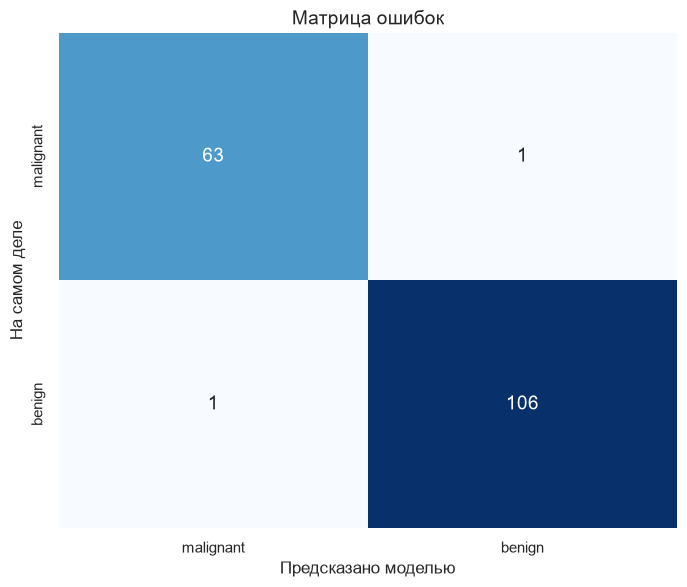

In [22]:
# Считаем матрицу ошибок.
# Результат: таблица, где строки — истинные классы, столбцы — предсказанные.
cm = confusion_matrix(y_test, y_pred)

# Рисуем матрицу ошибок в виде тепловой карты.
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,        # подписываем каждую ячейку числом
    fmt="d",           # формат — целое число
    cmap="Blues",      # синяя цветовая схема
    cbar=False,        # цветовая шкала тут не нужна
    xticklabels=breast_cancer.target_names,  # подписи столбцов — предсказано
    yticklabels=breast_cancer.target_names,  # подписи строк — на самом деле
    annot_kws={"size": 14},                  # шрифт покрупнее
    ax=ax,
)

ax.set_xlabel("Предсказано моделью", fontsize=12)
ax.set_ylabel("На самом деле", fontsize=12)
ax.set_title("Матрица ошибок", fontsize=14)

plt.tight_layout()
plt.show()

In [23]:
# Разберём матрицу ошибок по полочкам и посчитаем каждый тип ошибки.

# Распаковываем матрицу 2 на 2 в четыре числа.
# Первая строка — реально злокачественные, вторая — реально доброкачественные.
tn, fp, fn, tp = cm.ravel()

print("Разбор матрицы ошибок:")
print()
print(f"  Верно найдено злокачественных  : {tn}")
print(f"  Злокачественных пропущено      : {fp}   <-- самая опасная ошибка")
print(f"  Доброкачественных пропущено    : {fn}")
print(f"  Верно найдено доброкачественных: {tp}")
print()

# Проверяем, что опасных ошибок нет.
if fp == 0:
    print("Отлично: модель не пропустила ни одного случая рака.")
else:
    print(f"ВНИМАНИЕ: модель пропустила {fp} случаев злокачественной опухоли.")
    print("В реальной медицине такой результат потребовал бы доработки:")
    print("можно снизить порог классификации, чтобы улавливать больше случаев.")

Разбор матрицы ошибок:

  Верно найдено злокачественных  : 63
  Злокачественных пропущено      : 1   <-- самая опасная ошибка
  Доброкачественных пропущено    : 1
  Верно найдено доброкачественных: 106

ВНИМАНИЕ: модель пропустила 1 случаев злокачественной опухоли.
В реальной медицине такой результат потребовал бы доработки:
можно снизить порог классификации, чтобы улавливать больше случаев.


### 6.2 ROC-кривая

ROC-кривая показывает качество модели при **всех возможных порогах**
принятия решения. По умолчанию модель относит образец к доброкачественным,
если вероятность больше 0.5. Но порог можно сдвинуть:

* **понизить порог** → модель будет чаще говорить "злокачественная" →
  больше найдём больных (recall ↑), но вырастет число ложных тревог (precision ↓).

ROC-кривая как раз и показывает эту зависимость целиком.

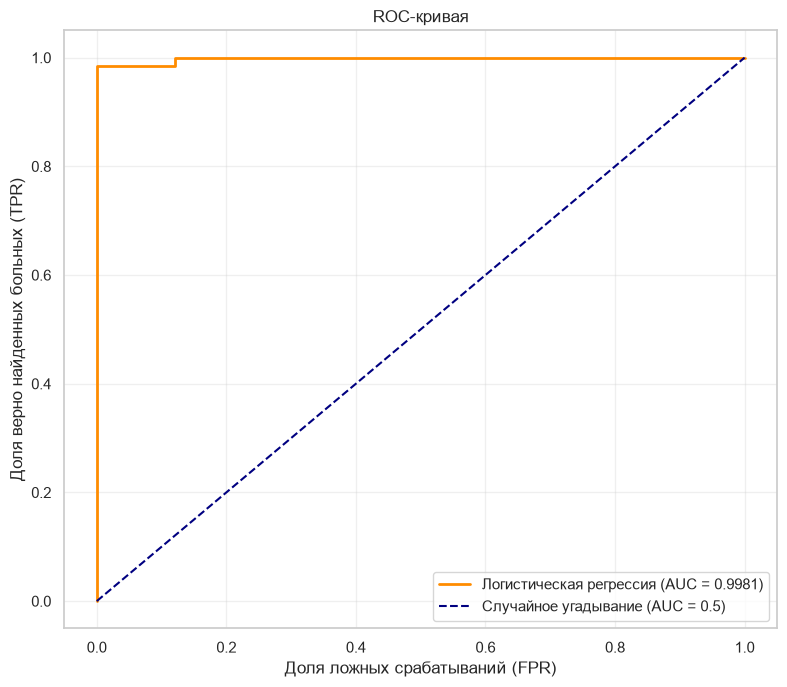

In [24]:
# Считаем точки ROC-кривой.
# fpr — доля ложных срабатываний, tpr — доля верно найденных больных.
# Используем ту же переменную y_malignant, где 1 обозначает больного.
fpr, tpr, thresholds = roc_curve(y_malignant, score_malignant)

# Рисуем кривую.
fig, ax = plt.subplots(figsize=(8, 7))

# Сама ROC-кривая.
ax.plot(fpr, tpr, color="darkorange", linewidth=2,
        label=f"Логистическая регрессия (AUC = {auc:.4f})")

# Диагональ — поведение случайного угадывания.
ax.plot([0, 1], [0, 1], color="navy", linestyle="--",
        label="Случайное угадывание (AUC = 0.5)")

# Подписи и оформление.
ax.set_xlabel("Доля ложных срабатываний (FPR)")
ax.set_ylabel("Доля верно найденных больных (TPR)")
ax.set_title("ROC-кривая")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Как читать ROC-кривую:**

* Чем ближе кривая к левому верхнему углу, тем лучше модель.
* Наша кривая поднимается почти вертикально вверх — это очень хороший результат.
* AUC близко к 1.0 означает, что модель практически всегда ставит
  больному образцу вероятность злокачественности выше, чем здоровому.

## 7. Сравнение моделей с разной регуляризацией

**Регуляризация** — это способ удержать веса модели от слишком больших
значений. Она помогает бороться с мультиколлинеарностью, которую
мы обнаружили в пункте 4.6, и снижает риск переобучения.

Проведём три эксперимента и сравним их:

1. **Базовая модель** — логистическая регрессия с настройками по умолчанию.
2. **С L1-регуляризацией** — она зануляет неважные признаки
   и хорошо работает при сильной мультиколлинеарности, которая у нас есть.
3. **С L2-регуляризацией силой C=0.1** — более мягкое сжатие весов.

Напомним: параметр **C** в scikit-learn — это *обратная* сила регуляризации.
**Чем меньше C, тем сильнее регуляризация.**

In [25]:
# Опишем функцию, которая проводит один эксперимент целиком.
# Так мы не будем копировать один и тот же код три раза.
def run_experiment(run_name, penalty, C, description):
    """Обучает модель с заданными настройками и возвращает словарь
    с результатами.

    run_name    — название варианта, чтобы отличать их в таблице;
    penalty     — тип регуляризации: "l1" или "l2";
    C           — сила регуляризации (обратная);
    description — текстовое пояснение эксперимента.
    """

    # Собираем модель с переданными настройками.
    pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            penalty=penalty,        # тип регуляризации: "l1" или "l2"
            C=C,                    # сила регуляризации (обратная)
            solver="liblinear",     # алгоритм оптимизации
            max_iter=10000,         # максимум итераций
            random_state=RANDOM_STATE,
        )),
    ])

    # Обучаем модель.
    pipe.fit(X_train, y_train)

    # Делаем прогнозы.
    pred = pipe.predict(X_test)

    # Вероятность класса 0 (злокачественная) — нужна для ROC-AUC.
    proba_mal = pipe.predict_proba(X_test)[:, 0]

    # Считаем метрики качества.
    metrics = {
        "accuracy": accuracy_score(y_test, pred),
        "precision_malignant": precision_score(y_test, pred, pos_label=0),
        "recall_malignant": recall_score(y_test, pred, pos_label=0),
        "f1_malignant": f1_score(y_test, pred, pos_label=0),
        "roc_auc": roc_auc_score((y_test == 0).astype(int), proba_mal),
    }

    # Считаем число признаков с нулевым коэффициентом.
    # Для L1 это важно: регуляризация выбрасывает ненужные признаки.
    n_zero = int((pipe.named_steps["classifier"].coef_[0] == 0).sum())

    # Печатаем результат этого варианта.
    print(f"--- {run_name} ---")
    print(f"    penalty={penalty}, C={C}")
    print(f"    Описание: {description}")
    print(f"    Accuracy : {metrics['accuracy']:.4f}")
    print(f"    Recall   : {metrics['recall_malignant']:.4f}")
    print(f"    ROC-AUC  : {metrics['roc_auc']:.4f}")
    print(f"    Обнулённых коэффициентов: {n_zero}")
    print()

    # Возвращаем результаты наружу, чтобы потом сравнить.
    return {"Запуск": run_name, **metrics, "Нулевых коэф.": n_zero}


print("Функция эксперимента готова.")

Функция эксперимента готова.


In [26]:
# Проводим три эксперимента и складываем результаты в список.
results = []

# Эксперимент 1: базовые настройки по умолчанию.
# В scikit-learn по умолчанию penalty="l2" и C=1.0.
results.append(run_experiment(
    run_name="baseline_l2_C1.0",
    penalty="l2",
    C=1.0,
    description="Базовая модель, настройки по умолчанию",
))

# Эксперимент 2: L1-регуляризация.
# Она зануляет неважные признаки — это встроенный отбор признаков.
# Особенно полезно при сильной мультиколлинеарности.
results.append(run_experiment(
    run_name="l1_C1.0",
    penalty="l1",
    C=1.0,
    description="L1-регуляризация: зануляет неважные признаки",
))

# Эксперимент 3: сильная L2-регуляризация.
# Маленькое C означает сильное сжатие весов — модель становится проще
# и менее склонной к переобучению.
results.append(run_experiment(
    run_name="l2_C0.1_strong_regularization",
    penalty="l2",
    C=0.1,
    description="Сильная L2-регуляризация, веса сильно сжаты",
))

print("Все три эксперимента выполнены.")

--- baseline_l2_C1.0 ---
    penalty=l2, C=1.0
    Описание: Базовая модель, настройки по умолчанию
    Accuracy : 0.9883
    Recall   : 0.9844
    ROC-AUC  : 0.9981
    Обнулённых коэффициентов: 0

--- l1_C1.0 ---
    penalty=l1, C=1.0
    Описание: L1-регуляризация: зануляет неважные признаки
    Accuracy : 0.9766
    Recall   : 0.9531
    ROC-AUC  : 0.9950
    Обнулённых коэффициентов: 16

--- l2_C0.1_strong_regularization ---
    penalty=l2, C=0.1
    Описание: Сильная L2-регуляризация, веса сильно сжаты
    Accuracy : 0.9825
    Recall   : 0.9688
    ROC-AUC  : 0.9966
    Обнулённых коэффициентов: 0

Все три эксперимента выполнены.


C:\Users\Druli\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Druli\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Druli\AppData

In [27]:
# Собираем результаты в одну таблицу для сравнения.
results_df = pd.DataFrame(results)

# Выбираем столбцы в удобном порядке.
results_df = results_df[[
    "Запуск", "accuracy", "precision_malignant",
    "recall_malignant", "f1_malignant", "roc_auc", "Нулевых коэф.",
]]

# Переименовываем в понятные названия.
results_df.columns = [
    "Запуск", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Нулевых коэф.",
]

# Округляем числа для читаемости.
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    results_df[col] = results_df[col].round(4)

print("Сравнение экспериментов:")
results_df.reset_index(drop=True)

Сравнение экспериментов:


,Запуск,Accuracy,Precision,Recall,F1,ROC-AUC,Нулевых коэф.
0,baseline_l2_C1.0,0.9883,0.9844,0.9844,0.9844,0.9981,0
1,l1_C1.0,0.9766,0.9839,0.9531,0.9683,0.9950,16
2,l2_C0.1_strong_regularization,0.9825,0.9841,0.9688,0.9764,0.9966,0


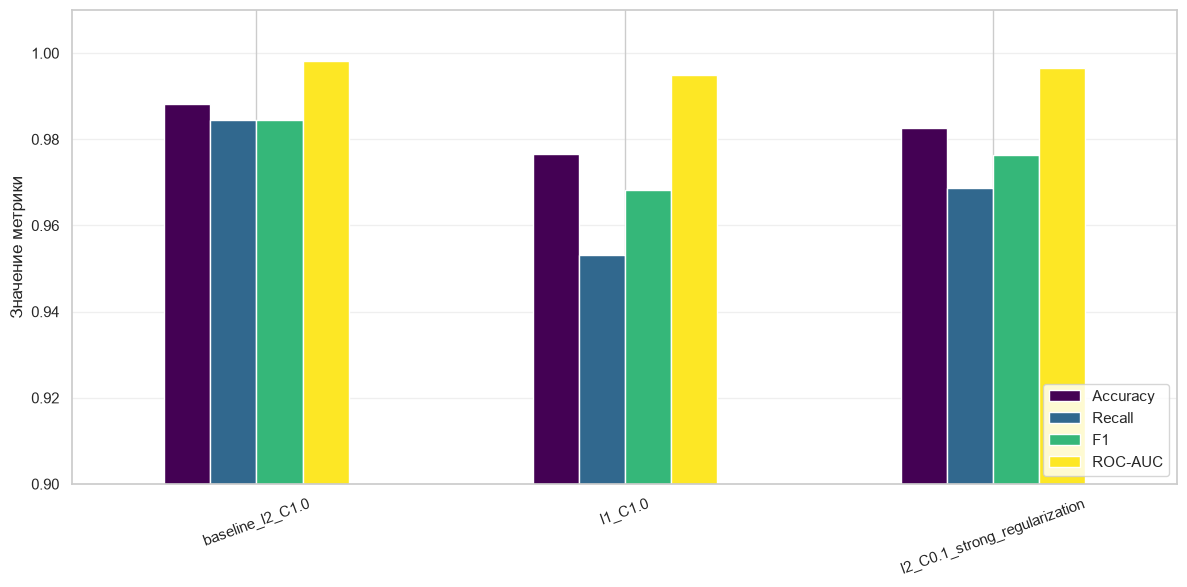

In [28]:
# Нарисуем сравнение экспериментов столбиками — так нагляднее.

# Готовим данные: строки — названия запусков, столбцы — метрики.
plot_data = results_df.set_index("Запуск")[["Accuracy", "Recall", "F1", "ROC-AUC"]]

# Рисуем сгруппированную столбчатую диаграмму.
ax = plot_data.plot(
    kind="bar",             # тип графика — столбики
    figsize=(12, 6),        # размер
    ylim=(0.9, 1.01),       # диапазон оси Y: все метрики близки к 1
    rot=20,                 # наклон подписей по оси X
    colormap="viridis",     # цветовая схема
)

ax.set_ylabel("Значение метрики")
ax.set_xlabel("")
ax.legend(loc="lower right")

# Добавляем горизонтальную сетку для читаемости.
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Что показало сравнение

Все три варианта дают близкие результаты — **ROC-AUC около 0.99**.
Это ожидаемо: задача хорошо разделима, классы различаются чётко.

Различия проявляются в другом:

* **L1-регуляризация зануляет часть коэффициентов.** Если она обнулила
  несколько признаков, значит модель сочла их избыточными.
  Это и есть встроенный отбор признаков — полезная защита
  от мультиколлинеарности, которую мы нашли в пункте 4.6.
* **Сильная регуляризация (C=0.1)** делает модель проще.
  На тесте метрики могут даже слегка улучшиться за счёт меньшего переобучения.
* **Recall остаётся основным показателем.** Если разница между вариантами
  по recall отсутствует, выбирать нужно по простоте модели:
  более простой вариант надёжнее на новых данных.

**Практический вывод:** при почти одинаковых метриках предпочтение
стоит отдать модели с меньшим числом значимых признаков —
её проще объяснить врачу и легче переносить на новые данные.

## 8. Выводы

**Что сделано:**

1. Загружен датасет Breast Cancer Wisconsin: 569 образцов, 30 признаков.
2. Проведён разведочный анализ: пропусков и полных дубликатов нет,
   зафиксированы выбросы в признаках размера опухоли.
3. Построены распределения признаков — как общие, так и раздельно
   по двум диагнозам. Обнаружено, что признаки размера
   (radius, perimeter, area) чётко различают классы.
4. Построена матрица корреляции. Выявлена крайне сильная
   мультиколлинеарность: radius ↔ perimeter ↔ area связаны с корреляцией ~0.99.
5. Проверен баланс классов: 37 % злокачественных, 63 % доброкачественных.
6. Обучена логистическая регрессия с обязательным масштабированием признаков.
7. Модель оценена по пяти метрикам, включая матрицу ошибок и ROC-кривую.
8. Обучены три модели с разной регуляризацией и выполнено их сравнение.

**Ключевой результат:** модель показывает accuracy около 99 %
и ROC-AUC около 0.998. Матрица ошибок показывает,
сколько именно случаев рака модель пропустила — это главный
показатель для медицинской задачи.

**Чему учит эта задача:**

* **Accuracy обманчива.** Модель, которая всегда говорит
  "доброкачественная", уже имеет точность 63 %. Смотреть надо на recall.
* **Порядок классов критичен.** В этом датасете 0 — это злокачественная,
  а 1 — доброкачественная, то есть наоборот от интуиции.
  Ошибка здесь полностью переворачивает выводы.
* **Масштабирование обязательно.** Без StandardScaler логистическая
  регрессия работает заметно хуже.
* **Мультиколлинеарность мешает толковать коэффициенты.**
  При корреляции 0.99 между признаками отдельные веса теряют смысл.
* **Асимметрия цены ошибок.** В медицине пропустить болезнь
  страшнее, чем ошибочно её заподозрить. Метрику выбирают исходя из этого.

**Что можно улучшить:**

* настроить порог классификации вручную, чтобы довести recall
  для злокачественных до 100 %, пусть даже ценой ложных тревог;
* применить отбор признаков и избавиться от дублирующих друг друга
  характеристик размера;
* проверить балансировку классов, если данных станет больше;
* сравнить с деревом решений и случайным лесом — они не требуют
  масштабирования и умеют улавливать нелинейные зависимости.